In [1]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import os

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import json
import numpy as np
import math
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split , cross_val_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.svm import SVC 
from keras.utils import to_categorical
from keras.layers import LSTM, Dense, Dropout

# Példa adathalmaz (45 videó, mindegyikben 25 frame, 25 kulcspont, 2 adat)


In [2]:
input_files = [
    "bent-over_rows",
    "biceps",
    "latheral_raises",
    "rdl",
    "shoulder_press",
    "squat"
]

In [3]:
def calculateFrameVectors(json_file, frame_idx):
    frame1 = json_file['frames'][frame_idx]
    frame2 = json_file['frames'][frame_idx+1]

    #a két kép közötti kulcspontokból csinál vektorokat
    frameDatas=[]

    for i in range(len(frame1['keypoints'])):
        vector=[]
        # vector.append(frame1['keypoints'][i]['x'])
        # vector.append(frame1['keypoints'][i]['y'])
        

        vector.append(frame2['keypoints'][i]['x']- frame1['keypoints'][i]['x'])
        vector.append(frame2['keypoints'][i]['y']- frame1['keypoints'][i]['y'])
        # vector.append(frame2['keypoints'][i]['depth']- frame1['keypoints'][i]['depth'])
        
        frameDatas.append(vector)
    return frameDatas

In [4]:
base_path = r"C:\Users\Legion\Documents\Projektmunka\DepthBasics-WPF\bin\Debug\frames"
data= []
Y_train=[]

X_test=[]
Y_test=[]

for file_name in input_files:  # Fájlnév iteráció
    file_folder_path = os.path.join(base_path, file_name)

    contents= os.listdir(file_folder_path)

    trainingSize=0.2*len(contents)


    for i in range(len(contents)): 


        file_path = os.path.join(file_folder_path, contents[i])

        with open(file_path, "r") as f:
            

            json_file=json.load(f)
            movement=[]


            for frame_idx in range(len(json_file['frames'])-1): 
                frameDatas=calculateFrameVectors(json_file, frame_idx)
                movement.append(frameDatas)
                if(len(movement)==25):  
                    if i<trainingSize :
                        X_test.append(movement)  
                        Y_test.append(json_file['video_name'])
                        movement=[]
                    else :
                        data.append(movement)
                        Y_train.append(json_file['video_name'])
                        movement=[]

X_train= np.array(data)
Y_train= np.array(Y_train)
X_test= np.array(X_test)
Y_test = np.array(Y_test)


print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test .shape)

(217, 25, 25, 2)
(217,)
(67, 25, 25, 2)
(67,)


In [5]:
X_train = X_train.reshape(217, 25, -1)

X_test= X_test.reshape(67, 25, -1)

In [6]:
encoder = LabelEncoder()
Y_train = encoder.fit_transform(Y_train)
Y_train = to_categorical(Y_train)

Y_test = encoder.fit_transform(Y_test)
Y_test = to_categorical(Y_test)

In [14]:
model=Sequential()

In [31]:
from keras.optimizers import Adam
from keras.models import Sequential
model = Sequential()
model.add(LSTM(64, return_sequences=True))
model.add(Dropout(0.5))
model.add(LSTM(64, return_sequences=False, kernel_regularizer='l2'))
model.add(Dropout(0.3))

model.add(Dense(16, activation='relu', kernel_regularizer='l2', bias_regularizer='l2'))
model.add(Dense(Y_train.shape[1], activation='softmax'))

optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

In [32]:

from keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True)

train_history = model.fit( X_train , Y_train ,validation_data=(X_test, Y_test), batch_size =  15, epochs = 20,validation_split = 0.2 , verbose = 1  )
# train_history = model.fit( X_train , Y_train ,validation_data=(X_test, Y_test), batch_size =  10, epochs = 20,validation_split = 0.2 , verbose = 1 ,callbacks=early_stopping )


Epoch 1/20
15/15 [==============================] - 6s 93ms/step - loss: 2.9654 - accuracy: 0.1797 - val_loss: 2.7569 - val_accuracy: 0.3881
Epoch 2/20
15/15 [==============================] - 0s 21ms/step - loss: 2.6148 - accuracy: 0.4101 - val_loss: 2.3974 - val_accuracy: 0.3881
Epoch 3/20
15/15 [==============================] - 0s 20ms/step - loss: 2.2398 - accuracy: 0.4747 - val_loss: 1.9177 - val_accuracy: 0.5224
Epoch 4/20
15/15 [==============================] - 0s 22ms/step - loss: 1.7669 - accuracy: 0.6083 - val_loss: 1.4653 - val_accuracy: 0.7612
Epoch 5/20
15/15 [==============================] - 0s 20ms/step - loss: 1.3571 - accuracy: 0.8157 - val_loss: 1.1838 - val_accuracy: 0.7910
Epoch 6/20
15/15 [==============================] - 0s 21ms/step - loss: 1.0188 - accuracy: 0.9263 - val_loss: 1.0124 - val_accuracy: 0.8806
Epoch 7/20
15/15 [==============================] - 0s 20ms/step - loss: 0.8467 - accuracy: 0.9447 - val_loss: 0.8522 - val_accuracy: 0.8955
Epoch 8/20
15

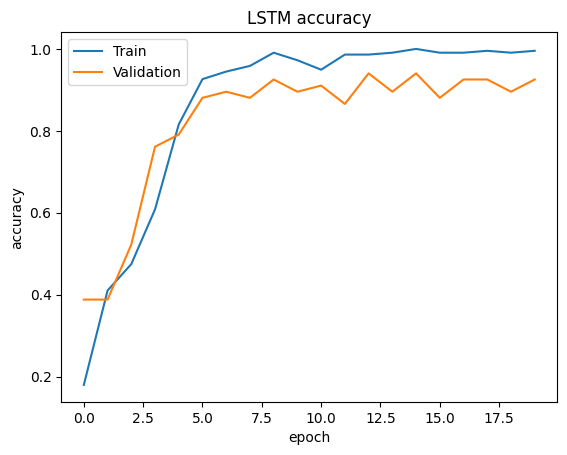

In [33]:
plt.plot(train_history.history['accuracy'])
plt.plot(train_history.history['val_accuracy'])
plt.title('LSTM accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [34]:
y_pred= model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)  # Több osztály esetén (softmax)
Y_test_classes = np.argmax(Y_test, axis=1)  # One-hot kódolt címkék átalakítása



print(accuracy_score(Y_test_classes, y_pred_classes))


3/3 [==============================] - 1s 4ms/step
0.9253731343283582


3/3 [==============================] - 0s 6ms/step


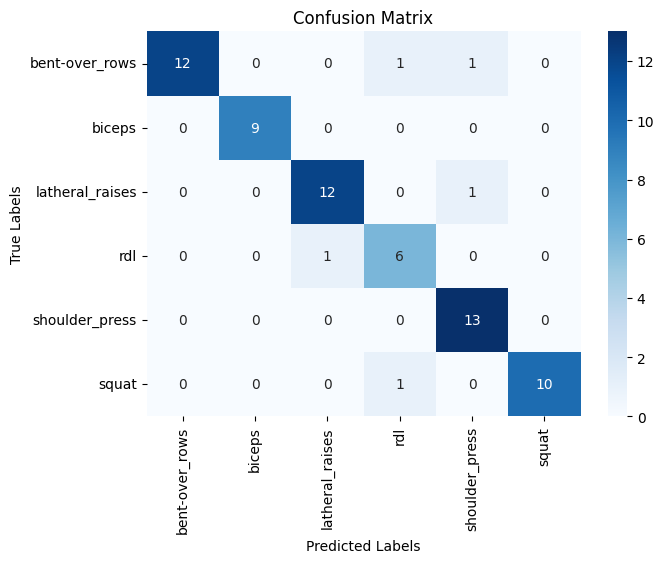

In [35]:
y_pred=model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Prediktált osztályok
y_true_classes = np.argmax(Y_test, axis=1)  # Valós osztályok

# Konfúziós mátrix létrehozása
cm = confusion_matrix(y_true_classes, y_pred_classes)

# Opcionális: Megfelelő osztálycímkék megadása
corr_labels = input_files  # Példa, itt az osztályneveket adod meg

# Kirajzolás Seaborn segítségével
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=corr_labels, yticklabels=corr_labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [36]:
model.summary()

Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_12 (LSTM)              (None, 25, 64)            29440     
                                                                 
 dropout_12 (Dropout)        (None, 25, 64)            0         
                                                                 
 lstm_13 (LSTM)              (None, 64)                33024     
                                                                 
 dropout_13 (Dropout)        (None, 64)                0         
                                                                 
 dense_12 (Dense)            (None, 16)                1040      
                                                                 
 dense_13 (Dense)            (None, 6)                 102       
                                                                 
Total params: 63,606
Trainable params: 63,606
Non-trai

In [107]:

X_new=[]
Y_new=[]

for file_name in os.listdir('converted_files'):  # Fájlnév iteráció
    # contents= os.listdir('converted')

    with open(f'converted_files/{file_name}', "r") as f:
        

        json_file=json.load(f)
        movement=[]


        for frame_idx in range(len(json_file['frames'])-1): 
            frameDatas=calculateFrameVectors(json_file, frame_idx)
            movement.append(frameDatas)
            if(len(movement)==25):  
                X_new.append(movement)
                Y_new.append(json_file['video_name'])
                movement=[]

X_new= np.array(X_new)
Y_new= np.array(Y_new)

print(X_new.shape)
print(Y_new.shape)

(30, 25, 25, 2)
(30,)


In [108]:
X_new= X_new.reshape(30,25,-1)

Y_new=encoder.fit_transform(Y_new)
Y_new= to_categorical(Y_new)


In [109]:
pred_new = model.predict(X_new)
pred_new

1/1 [==============================] - 0s 41ms/step


array([[9.80089068e-01, 1.77720760e-03, 4.10524104e-03, 8.75383057e-03,
        4.88425046e-03, 3.90410743e-04],
       [9.56576288e-01, 3.30271618e-03, 1.01404823e-02, 1.02585722e-02,
        1.88049767e-02, 9.17035853e-04],
       [9.83858407e-01, 1.55662093e-03, 2.96387332e-03, 8.33662599e-03,
        2.99650338e-03, 2.88005656e-04],
       [9.83391523e-01, 1.49322825e-03, 3.62875406e-03, 6.74551772e-03,
        4.43470804e-03, 3.06238042e-04],
       [8.03854549e-04, 9.92702723e-01, 2.50214222e-03, 7.20730983e-04,
        2.38950853e-03, 8.81049316e-04],
       [8.57049890e-04, 9.92220938e-01, 2.64624786e-03, 7.73169566e-04,
        2.55791727e-03, 9.44652595e-04],
       [7.44019868e-04, 9.92877424e-01, 2.27939128e-03, 6.75247982e-04,
        2.55271816e-03, 8.71166936e-04],
       [7.46866979e-04, 9.93029773e-01, 2.31387583e-03, 6.72519440e-04,
        2.39261054e-03, 8.44348164e-04],
       [7.72462052e-04, 9.92905378e-01, 2.42894376e-03, 7.00769131e-04,
        2.33188621e-03, 

In [110]:
pred= np.argmax(pred_new, axis=1)
Y_new= np.argmax(Y_new, axis=1)


# print(Y_new)


In [111]:

print(accuracy_score(Y_new, pred))

0.9666666666666667


In [37]:
Y_new

NameError: name 'Y_new' is not defined

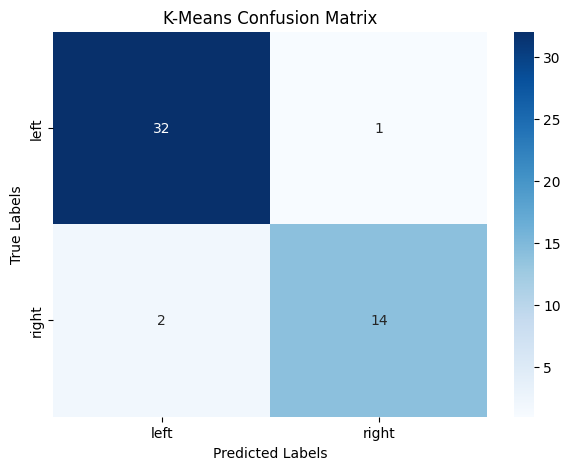

In [40]:
Y_new=[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,1]
pred= [0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,1,1,0,1,1,1,1,1,1,1,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,0]

cm = confusion_matrix(Y_new,pred)

# Opcionális: Megfelelő osztálycímkék megadása
corr_labels = ["left", "right"]  # Példa, itt az osztályneveket adod meg

# Kirajzolás Seaborn segítségével
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=corr_labels, yticklabels=corr_labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('K-Means Confusion Matrix')
plt.show()

In [113]:
model.save('LSTM_model')

INFO:tensorflow:Assets written to: LSTM_model\assets


INFO:tensorflow:Assets written to: LSTM_model\assets
